In [ ]:
#Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Makes charts look clean
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'Arial'

In [ ]:
#Loading the dataset

In [6]:
df= pd.read_excel(r"C:\Users\DELL\Desktop\AI_Analytics_Survey_20Q_150R.xlsx")

In [ ]:
#EDA process

In [7]:
df.head()

,Gender,Age Group,Industry,Role,Experience,Q1,Q2,Q3,Q4,Q5,...,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Technology,Diagnosis,Performance
0,Male,26-35,Manufacturing,Analyst,3-5 years,4,4,5,2,4,...,3,3,2,4,4,3,3,4.333333,3.333333,3.25
1,Prefer not to say,46-55,Government,Nurse,< 1 year,2,5,5,3,3,...,5,5,4,4,5,5,4,4.000000,2.666667,4.75
2,Male,26-35,Government,Doctor,5-10 years,4,5,4,5,1,...,1,4,5,2,3,2,5,4.333333,3.333333,2.75
3,Female,56+,Healthcare,Manager,5-10 years,2,5,5,4,3,...,5,2,3,1,5,5,5,4.000000,4.000000,4.00
4,Prefer not to say,46-55,Pharma,Nurse,3-5 years,4,5,4,4,4,...,2,2,2,4,2,5,4,4.333333,4.000000,2.75


In [10]:
df.shape

(150, 28)

In [26]:
df.isnull

<bound method DataFrame.isnull of                 Gender Age Group       Industry        Role  Experience  Q1  \
0                 Male     26-35  Manufacturing     Analyst   3-5 years   4   
1    Prefer not to say     46-55     Government       Nurse    < 1 year   2   
2                 Male     26-35     Government      Doctor  5-10 years   4   
3               Female       56+     Healthcare     Manager  5-10 years   2   
4    Prefer not to say     46-55         Pharma       Nurse   3-5 years   4   
..                 ...       ...            ...         ...         ...  ..   
145  Prefer not to say       56+         Retail      Doctor    < 1 year   4   
146             Female     26-35      Insurance     Manager   10+ years   4   
147             Female     36-45  IT/Technology    Director   3-5 years   3   
148               Male     46-55     Healthcare  Researcher   3-5 years   3   
149  Prefer not to say     46-55         Pharma       Nurse   3-5 years   4   

     Q2  Q3  Q4  

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gender       150 non-null    object 
 1   Age Group    150 non-null    object 
 2   Industry     150 non-null    object 
 3   Role         150 non-null    object 
 4   Experience   150 non-null    object 
 5   Q1           150 non-null    int64  
 6   Q2           150 non-null    int64  
 7   Q3           150 non-null    int64  
 8   Q4           150 non-null    int64  
 9   Q5           150 non-null    int64  
 10  Q6           150 non-null    int64  
 11  Q7           150 non-null    int64  
 12  Q8           150 non-null    int64  
 13  Q9           150 non-null    int64  
 14  Q10          150 non-null    int64  
 15  Q11          150 non-null    int64  
 16  Q12          150 non-null    int64  
 17  Q13          150 non-null    int64  
 18  Q14          150 non-null    int64  
 19  Q15     

In [11]:
df.columns

Index(['Gender', 'Age Group', 'Industry', 'Role', 'Experience', 'Q1', 'Q2',
       'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13',
       'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Technology',
       'Diagnosis', 'Performance'],
      dtype='object')

In [30]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Frequency distribution tables

In [12]:
q_labels = {
  'Q1': 'AI adoption in healthcare orgs',
  'Q2': 'Tech tools improve efficiency',
  'Q3': 'Early disease ID improves outcomes',
  'Q4': 'Analytical tools aid early detection',
  'Q5': 'Early diagnosis reduces cost',
  'Q6': 'Accurate diagnosis improves quality',
  'Q7': 'Advanced tech improves efficiency',
  'Q8': 'Tech insights aid decision-making',
  'Q9': 'Resource efficiency improves performance',
  'Q10': 'Analytics improves org performance',
  'Q11': 'AI reduces readmission rates',
  'Q12': 'Real-time AI monitoring improves safety',
  'Q13': 'Professionals are adequately trained',
  'Q14': 'AI helps personalise treatment plans',
  'Q15': 'AI integration is complex',
  'Q16': 'Data privacy is a major concern',
  'Q17': 'AI reduces admin burden',
  'Q18': 'AI leads to long-term financial benefits',
  'Q19': 'AI improves medical imaging accuracy',
  'Q20': 'AI adoption will grow in next 5 years'
}
likert_labels = ['Strongly Disagree','Disagree','Neutral','Agree','Strongly Agree']

In [13]:
results = []
for q in [f'Q{i}' for i in range(1,21)]:
    counts = df[q].value_counts().sort_index()
    row = {'Question': q, 'Label': q_labels[q]}
    for val, lbl in enumerate(likert_labels, 1):
        row[lbl] = counts.get(val, 0)
        row[lbl+' %'] = round(counts.get(val,0)/150*100, 1)
    row['Mean'] = round(df[q].mean(), 2)
    row['Std Dev'] = round(df[q].std(), 2)
    row['Agreement %'] = row['Agree %'] + row['Strongly Agree %']
    results.append(row)

freq_df = pd.DataFrame(results)

freq_df.to_excel('frequency_tables.xlsx', index=False)
print("Saved! Showing first 5 rows:")
freq_df[['Question','Label','Mean','Std Dev','Agreement %']].head()

Saved! Showing first 5 rows:


,Question,Label,Mean,Std Dev,Agreement %
0,Q1,AI adoption in healthcare orgs,3.54,1.12,58.6
1,Q2,Tech tools improve efficiency,3.85,1.10,70.0
2,Q3,Early disease ID improves outcomes,3.92,1.18,74.0
3,Q4,Analytical tools aid early detection,3.41,1.23,54.0
4,Q5,Early diagnosis reduces cost,3.72,1.19,67.3


In [ ]:
#Descriptive Statistics

In [14]:
q_cols = [f'Q{i}' for i in range(1,21)]

desc = df[q_cols].describe().T   # Transpose for readability
desc['variance'] = df[q_cols].var().round(2)
desc['median'] = df[q_cols].median()
desc['mode'] = df[q_cols].mode().iloc[0]

# Round everything nicely
desc = desc[['mean','std','variance','median','mode','min','max']].round(2)
desc.columns = ['Mean','Std Dev','Variance','Median','Mode','Min','Max']
desc.index = [q_labels[q] for q in q_cols]

desc.to_excel('descriptive_stats.xlsx')
desc

,Mean,Std Dev,Variance,Median,Mode,Min,Max
AI adoption in healthcare orgs,3.54,1.12,1.24,4.0,4,1.0,5.0
Tech tools improve efficiency,3.85,1.10,1.20,4.0,4,1.0,5.0
Early disease ID improves outcomes,3.92,1.18,1.40,4.0,5,1.0,5.0
Analytical tools aid early detection,3.41,1.23,1.50,4.0,4,1.0,5.0
Early diagnosis reduces cost,3.72,1.19,1.41,4.0,4,1.0,5.0
Accurate diagnosis improves quality,3.99,1.03,1.07,4.0,5,1.0,5.0
Advanced tech improves efficiency,3.53,1.08,1.18,4.0,4,1.0,5.0
Tech insights aid decision-making,3.43,1.24,1.54,4.0,4,1.0,5.0
Resource efficiency improves performance,3.90,1.12,1.26,4.0,4,1.0,5.0
Analytics improves org performance,3.49,1.31,1.71,4.0,4,1.0,5.0


In [ ]:
#Charts for each construct

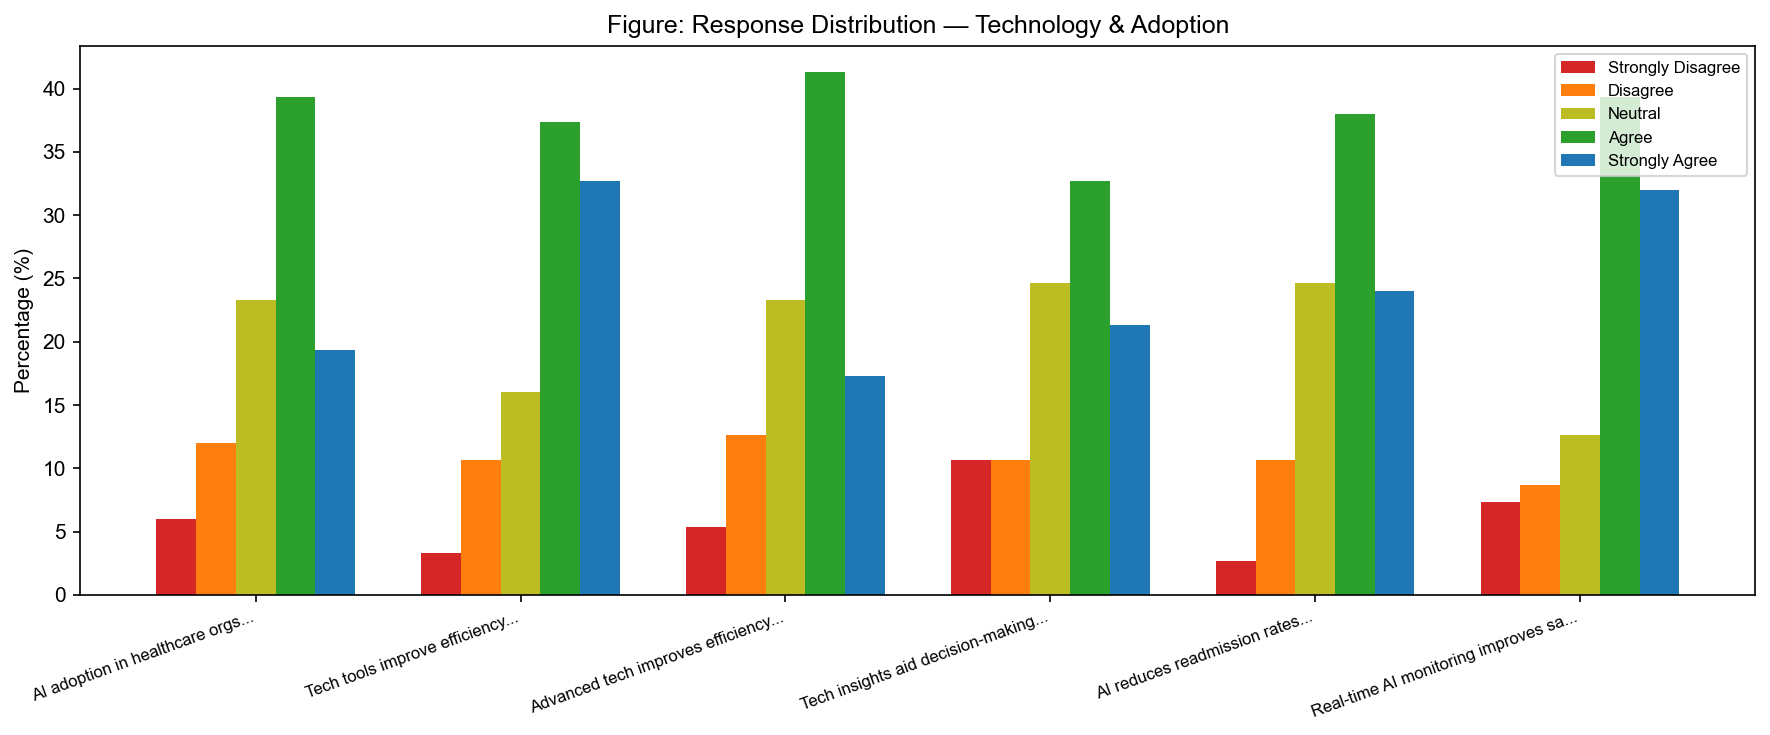

Saved: chart_Technology & Adoption.png


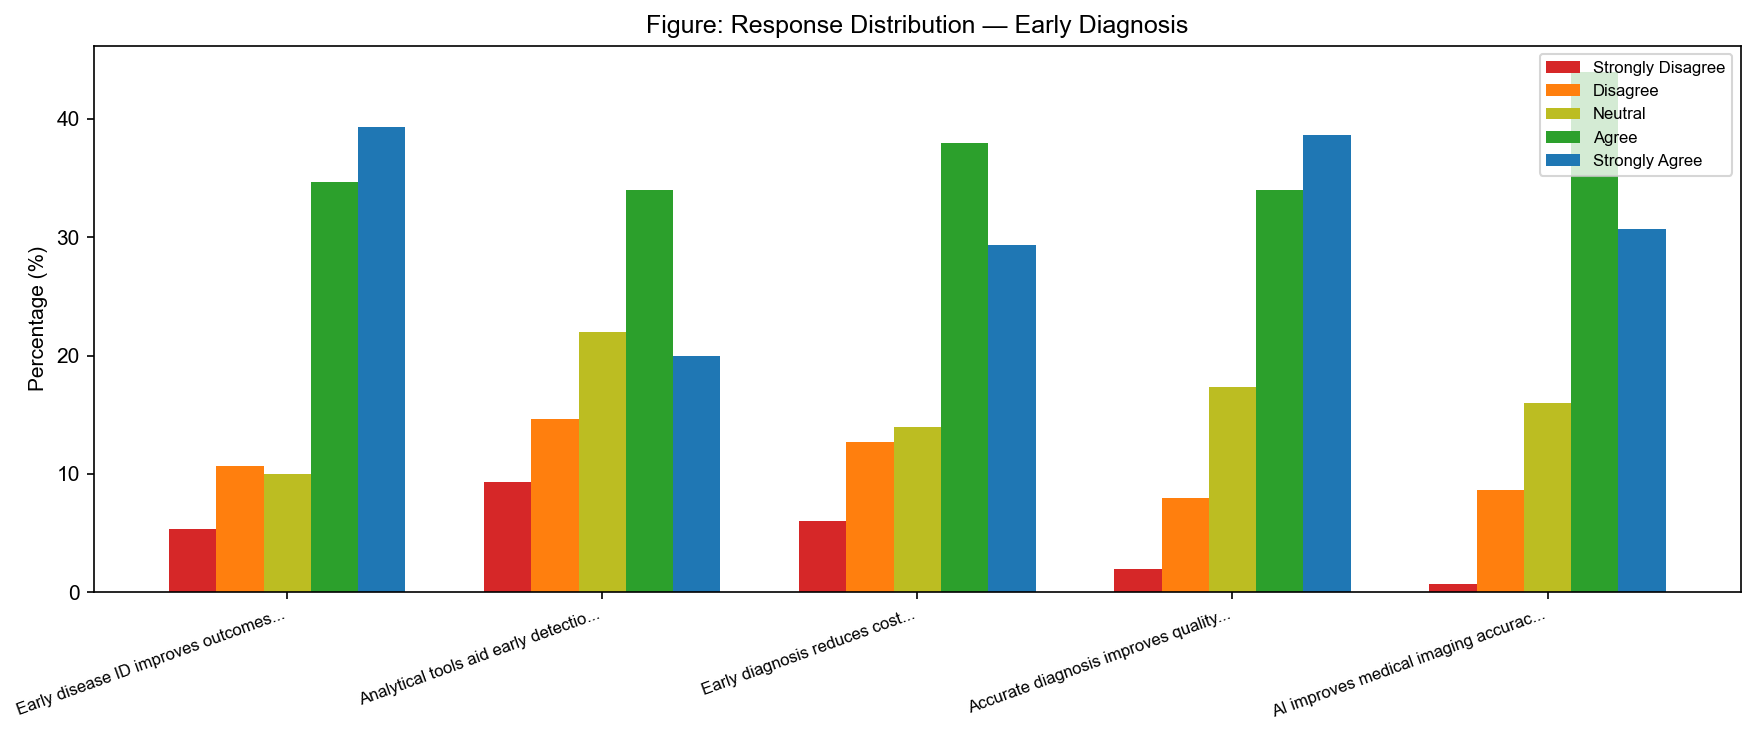

Saved: chart_Early Diagnosis.png


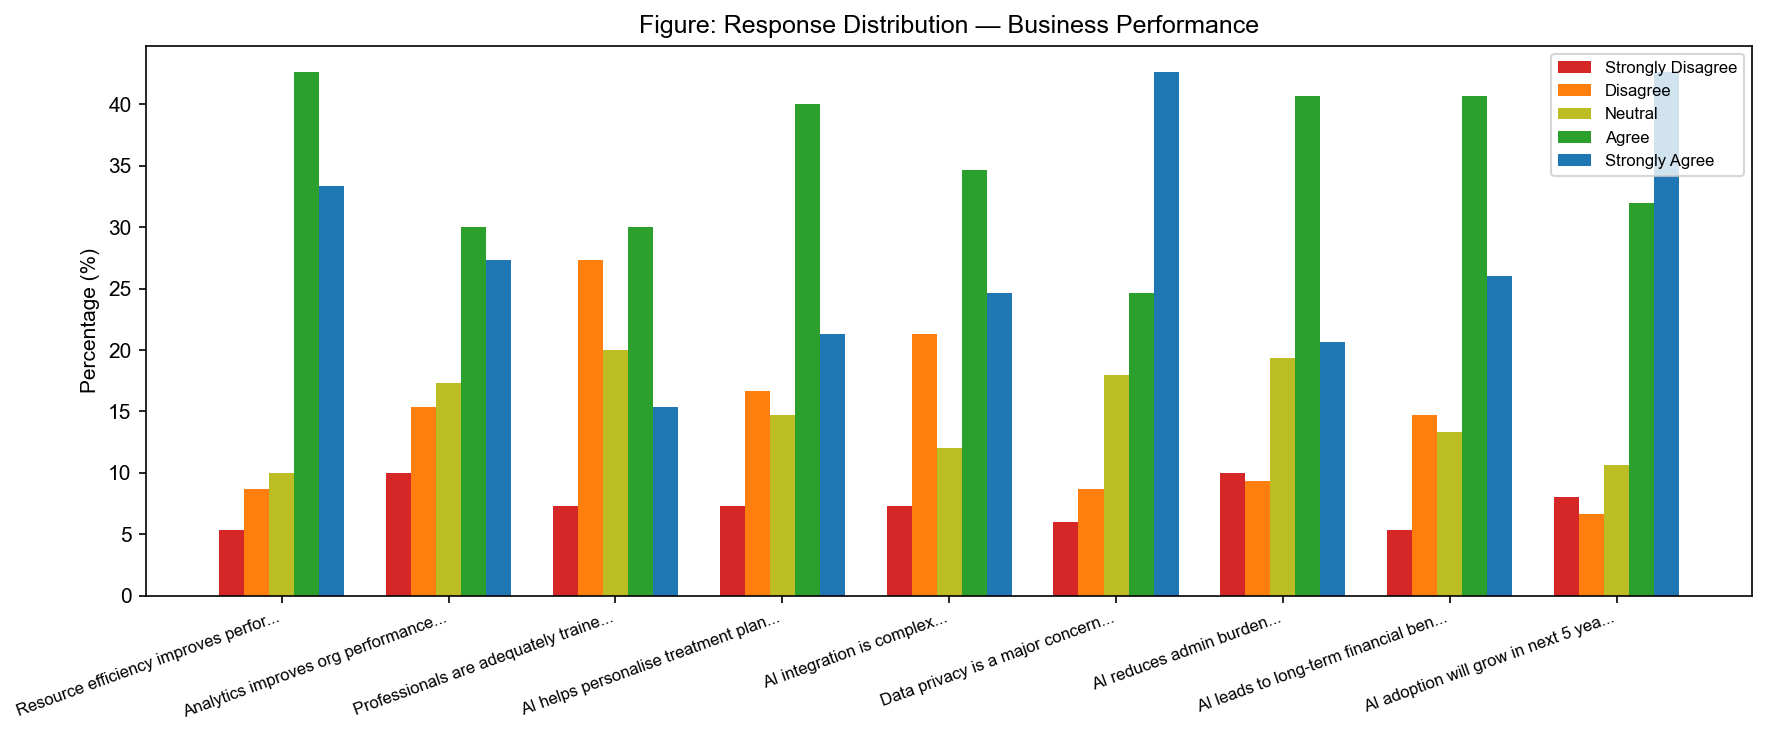

Saved: chart_Business Performance.png


In [15]:
constructs = {
  'Technology & Adoption': ['Q1','Q2','Q7','Q8','Q11','Q12'],
  'Early Diagnosis':        ['Q3','Q4','Q5','Q6','Q19'],
  'Business Performance':   ['Q9','Q10','Q13','Q14','Q15','Q16','Q17','Q18','Q20']
}
colors = ['#d62728','#ff7f0e','#bcbd22','#2ca02c','#1f77b4']

for name, qs in constructs.items():
    means = [df[q].value_counts(normalize=True).sort_index()*100 for q in qs]
    labels = [q_labels[q][:35]+'...' for q in qs]
    
    x = np.arange(len(qs))
    width = 0.15
    fig, ax = plt.subplots(figsize=(12,5))
    for i, lbl in enumerate(likert_labels):
        vals = [m.get(i+1,0) for m in means]
        ax.bar(x + i*width, vals, width, label=lbl, color=colors[i])
    
    ax.set_xticks(x + width*2)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Figure: Response Distribution — {name}', fontsize=12)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'chart_{name.replace(" ","_")}.png', dpi=150)
    plt.show()
    print(f"Saved: chart_{name}.png")

In [ ]:
#Demographic cross tabulation

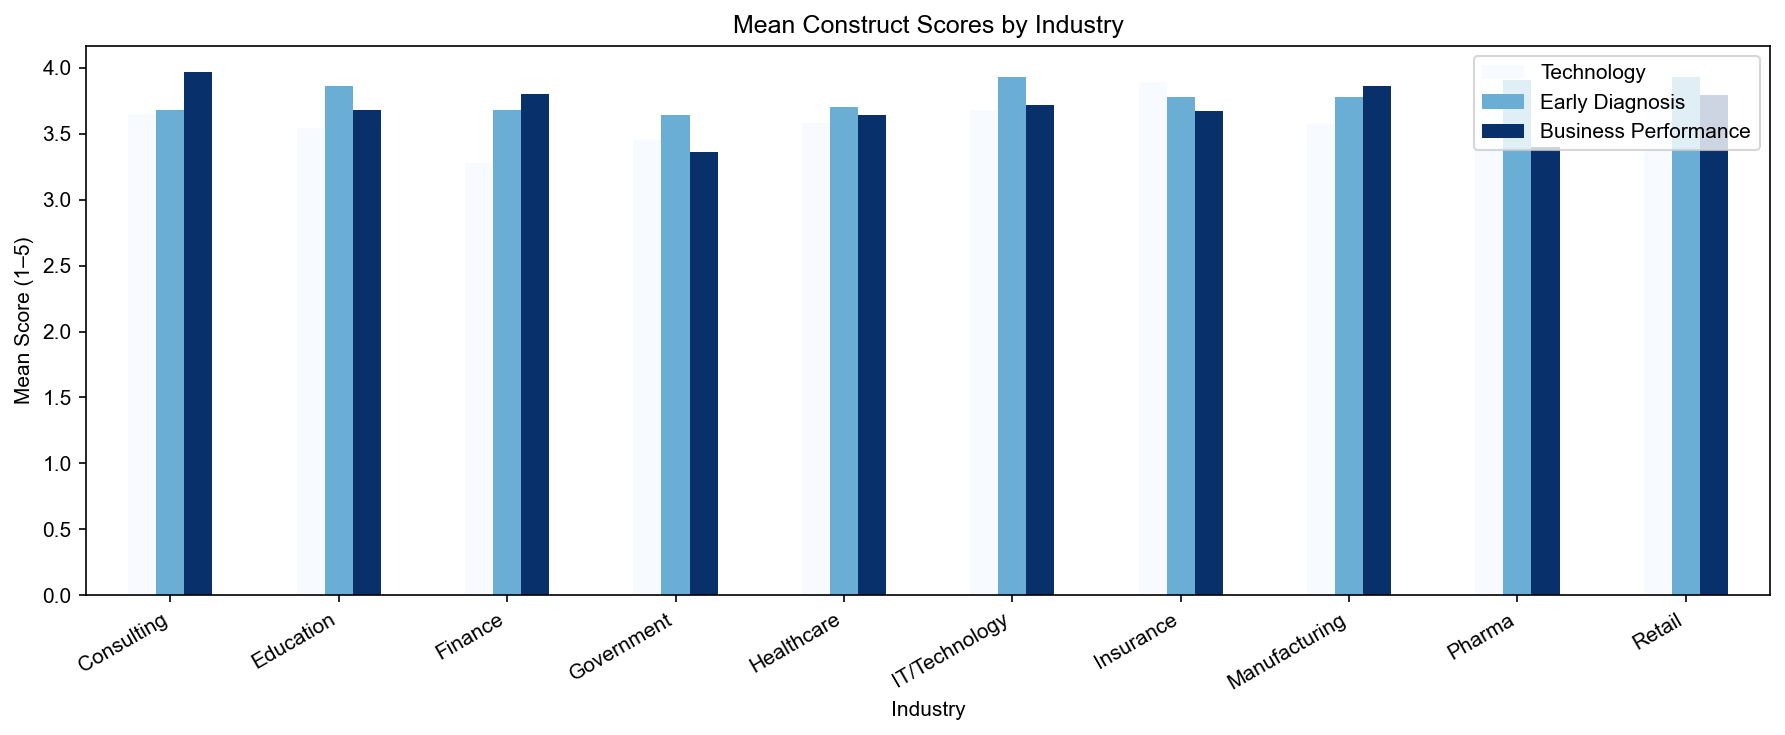

In [16]:
# Overall construct score per respondent
df['Tech_Score']  = df[['Q1','Q2','Q7','Q8']].mean(axis=1)
df['Diag_Score']  = df[['Q3','Q4','Q5','Q6','Q19']].mean(axis=1)
df['Perf_Score']  = df[['Q9','Q10','Q14','Q18','Q20']].mean(axis=1)

industry_analysis = df.groupby('Industry')[['Tech_Score','Diag_Score','Perf_Score']].mean().round(2)
industry_analysis.columns = ['Technology','Early Diagnosis','Business Performance']
industry_analysis.to_excel('industry_crosstab.xlsx')

# Plot it
industry_analysis.plot(kind='bar', figsize=(12,5), colormap='Blues')
plt.title('Mean Construct Scores by Industry')
plt.ylabel('Mean Score (1–5)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('industry_crosstab.png', dpi=150)
plt.show()

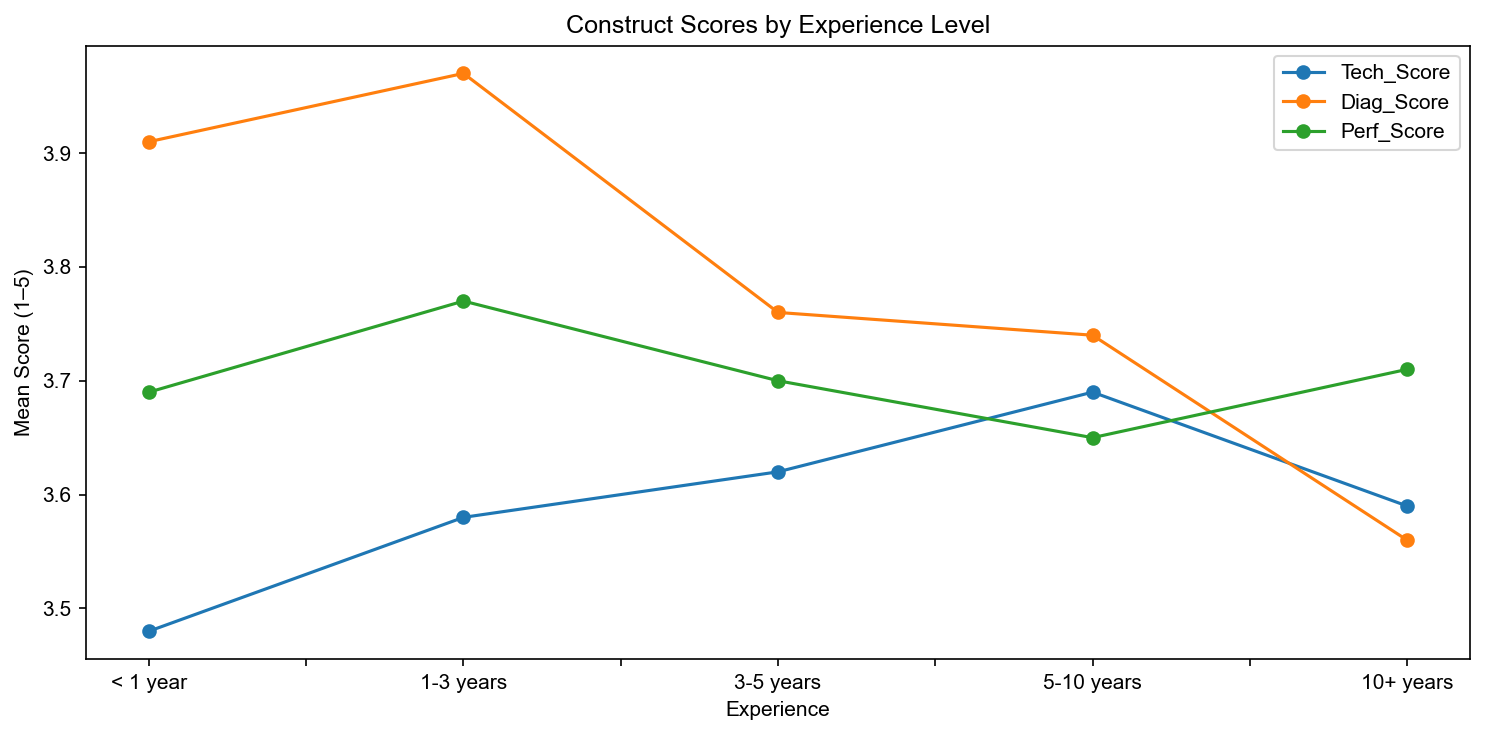

In [17]:
exp_order = ['< 1 year','1-3 years','3-5 years','5-10 years','10+ years']
exp_analysis = df.groupby('Experience')[['Tech_Score','Diag_Score','Perf_Score']].mean()
exp_analysis = exp_analysis.reindex(exp_order).round(2)
exp_analysis.to_excel('experience_crosstab.xlsx')
exp_analysis.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Construct Scores by Experience Level')
plt.ylabel('Mean Score (1–5)')
plt.tight_layout()
plt.savefig('experience_crosstab.png', dpi=150)
plt.show()

In [ ]:
#Cronbach's Alpha — reliability test

In [20]:
import pingouin as pg

construct_items = {
    'Technology & Adoption': ['Q1','Q2','Q7','Q8','Q11','Q12'],
    'Early Diagnosis':        ['Q3','Q4','Q5','Q6','Q19'],
    'Business Performance':   ['Q9','Q10','Q14','Q18','Q20'],
    'Challenges':             ['Q13','Q15','Q16'],
    'Full Questionnaire':     [f'Q{i}' for i in range(1,21)]
}

print("Reliability test/Cronbach's Alpha Results")
print("-"*45)
for name, items in construct_items.items():
    alpha = pg.cronbach_alpha(df[items])
    a_val = alpha[0]
    status = "✓ Acceptable" if a_val >= 0.7 else "✗ Low"
    print(f"{name:<28} α = {a_val:.3f}  {status}")

Reliability test/Cronbach's Alpha Results
---------------------------------------------
Technology & Adoption        α = -0.315  ✗ Low
Early Diagnosis              α = 0.061  ✗ Low
Business Performance         α = -0.196  ✗ Low
Challenges                   α = -0.044  ✗ Low
Full Questionnaire           α = -0.166  ✗ Low


In [ ]:
#ANOVA — test group differences

In [21]:
from scipy.stats import f_oneway, kruskal

print("=== ANOVA: AI Adoption Score by Industry ===")
groups = [grp['Tech_Score'].values for _, grp in df.groupby('Industry')]
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value:     {p_val:.3f}")
if p_val < 0.05:
    print("Result: Significant difference across industries (p < 0.05)")
else:
    print("Result: No significant difference across industries (p > 0.05)")

print()
print("=== Kruskal-Wallis: Performance Score by Experience ===")
groups2 = [grp['Perf_Score'].values for _, grp in df.groupby('Experience')]
h_stat, p_val2 = kruskal(*groups2)
print(f"H-statistic: {h_stat:.3f}")
print(f"P-value:     {p_val2:.3f}")
if p_val2 < 0.05:
    print("Result: Significant difference across experience groups (p < 0.05)")
else:
    print("Result: No significant difference (p > 0.05)")

=== ANOVA: AI Adoption Score by Industry ===
F-statistic: 1.345
P-value:     0.219
Result: No significant difference across industries (p > 0.05)

=== Kruskal-Wallis: Performance Score by Experience ===
H-statistic: 1.372
P-value:     0.849
Result: No significant difference (p > 0.05)


In [ ]:
#Final summary

In [22]:
print("="*55)
print("  Dissertation Analysis — Saket Sinha | 2412012010019")
print("  Transforming Healthcare Performance: AI Analytics")
print("="*55)
print(f"Total Respondents : {len(df)}")
print(f"Questions Analysed: 20")
print(f"Analyses Done     : 6 (Frequency, Descriptive, Charts,")
print(f"                    Cross-tab, Cronbach Alpha, ANOVA)")
print("Files Saved       : frequency_tables.xlsx")
print("                   descriptive_stats.xlsx")
print("                   industry_crosstab.xlsx")
print("                   3x chart PNG files")

  Dissertation Analysis — Saket Sinha | 2412012010019
  Transforming Healthcare Performance: AI Analytics
Total Respondents : 150
Questions Analysed: 20
Analyses Done     : 6 (Frequency, Descriptive, Charts,
                    Cross-tab, Cronbach Alpha, ANOVA)
Files Saved       : frequency_tables.xlsx
                   descriptive_stats.xlsx
                   industry_crosstab.xlsx
                   3x chart PNG files
